# Extreme climate & hydrological events characterisation

Companion notebook to `temporal_analysis.ipynb`. Goal: turn the **SPLI** (and other
standardized features) into **discrete extreme events** (drought / wet spells /
heatwaves), characterise each (duration, intensity, severity), and study
**compound** and **lagged** relationships (dry+hot, rain->groundwater delay).

**Method**
- *Standardized indices* (SPLI, SPI, SPEI, SSMI) are all N(0,1) by construction,
  so they live on the **same z-score scale** -> directly comparable / overlayable.
- *Run theory* (Yevjevich 1967): pick a threshold; an **event** is a run where the
  index stays below it. From each run you extract duration / peak / severity.

**Reference for the graphs**: https://www.brgm.fr/en/reference-completed-project/standardised-piezometric-level-indicator-spli-water-resource-management


### Setup

In [70]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from pathlib import Path
#from src.config import load_config
from scipy.stats import norm

#CONFIG = load_config()
#INPUT = Path(CONFIG["paths"]["data"]["interim"]) / "dataset_merged_featured_adc.csv"
INPUT = Path("..") / "data" / "interim" / "dataset_merged_featured_adc.csv"
df = pd.read_csv(INPUT).set_index("date_index")
df.index = pd.to_datetime(df.index); df = df.sort_index()


In [67]:
display(df.describe())
display(df.head())

,niveau_nappe_eau,latitude,longitude,temperature_2m_max,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_7d,Temperature_mean_30d
count,3402.000000,3.402000e+03,3.402000e+03,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000
mean,102.790735,4.268570e+01,2.685378e+00,20.562199,44048.910024,1.710435,15.430973,3.430038,52.564962,1017.082540,13.222986,0.184399,16.439888,11.972252,51.836684,157.211229,-50.193904,-146.206346,16.422804,16.422804
std,1.117116,7.106472e-15,4.441545e-16,7.605841,7838.631143,5.791315,7.866721,2.041003,29.938082,6.861055,7.610996,0.071702,5.653710,21.164641,48.571174,102.674766,85.960921,209.432464,5.631141,5.631141
min,100.060000,4.268570e+01,2.685378e+00,2.100000,32523.180000,0.000000,0.580000,0.160000,0.000000,989.200000,2.400000,0.046000,5.800000,0.000000,1.000000,25.000000,-241.890000,-537.930000,6.030000,6.030000
25%,101.940000,4.268570e+01,2.685378e+00,14.500000,36398.932500,0.000000,8.322500,1.720000,28.000000,1013.700000,7.100000,0.134000,11.400000,1.000000,19.200000,79.450000,-114.467500,-328.600000,11.330000,11.330000
50%,102.860000,4.268570e+01,2.685378e+00,19.800000,44038.160000,0.000000,15.090000,3.065000,54.000000,1017.300000,10.800000,0.165000,15.600000,4.700000,35.700000,129.350000,-49.685000,-131.355000,15.640000,15.640000
75%,103.800000,4.268570e+01,2.685378e+00,26.600000,51718.617500,0.700000,22.450000,4.950000,77.000000,1021.000000,17.900000,0.239000,21.700000,14.000000,69.600000,210.275000,3.870000,5.695000,21.710000,21.710000
max,104.630000,4.268570e+01,2.685378e+00,41.000000,55172.210000,111.200000,30.890000,11.550000,100.000000,1038.500000,41.900000,0.384000,28.300000,243.500000,299.300000,601.900000,271.880000,484.930000,27.900000,27.900000


,code_bss_x,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,temperature_2m_max,sunrise,sunset,...,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss_y,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_7d,Temperature_mean_30d
date_index,,,,,,,,,,,,,,,,,,,,,
2017-01-01,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-02,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-03,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,...,0.244,8.9,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-04,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,...,0.244,8.8,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-05,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,...,0.243,8.7,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77


In [68]:
df.columns

Index(['code_bss_x', 'bss_id', 'niveau_nappe_eau', 'mode_obtention',
       'nom_producteur', 'latitude', 'longitude', 'temperature_2m_max',
       'sunrise', 'sunset', 'daylight_duration', 'precipitation_sum',
       'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
       'cloud_cover_mean', 'pressure_msl_mean', 'wind_speed_10m_mean',
       'soil_moisture_0_to_100cm_mean', 'soil_temperature_0_to_100cm_mean',
       'code_bss_y', 'P_cum_7d', 'P_cum_30d', 'P_cum_90d', 'Peff_cum_30d',
       'Peff_cum_90d', 'Temperature_mean_7d', 'Temperature_mean_30d'],
      dtype='str')

In [ ]:
# Daily water balance = rain - reference ET (drives an SPEI-like index).
df["Peff"] = df["precipitation_sum"] - df["et0_fao_evapotranspiration"]

# Column roles
GWL  = "niveau_nappe_eau"                 # state -> aggregate by MEAN
SM   = "soil_moisture_0_to_100cm_mean"    # state -> aggregate by MEAN
PRCP = "precipitation_sum"                # flux  -> aggregate by SUM
PEFF = "Peff"                             # flux  -> aggregate by SUM
ET = "et0_fao_evapotranspiration"        # flux  -> aggregate by SUM
ST = "soil_temperature_0_to_100cm_mean"   # state -> aggregate by MEAN
SR = "shortwave_radiation_sum"            # flux  -> aggregate by SUM
WS = "wind_speed_10m_mean"                # state -> aggregate by MEAN
CC = "cloud_cover_mean"                   # state -> aggregate by MEAN
PMSL = "pressure_msl_mean"                # state -> aggregate by MEAN
# Heatwave needs daily MAX air temp
TMAX = "temperature_2m_max"
print("rows:", len(df), "| span:", df.index.min().date(), "->", df.index.max().date())
df[[GWL, PRCP, PEFF, SM, TMAX]].describe().round(2)

rows: 3402 | span: 2017-01-01 -> 2026-07-13


,niveau_nappe_eau,precipitation_sum,Peff,soil_moisture_0_to_100cm_mean,temperature_2m_max
count,3402.00,3402.00,3402.00,3402.00,3402.00
mean,102.79,1.71,-1.72,0.18,20.56
std,1.12,5.79,6.60,0.07,7.61
min,100.06,0.00,-11.55,0.05,2.10
25%,101.94,0.00,-4.80,0.13,14.50
50%,102.86,0.00,-2.52,0.16,19.80
75%,103.80,0.70,-1.01,0.24,26.60
max,104.63,111.20,110.97,0.38,41.00


### Generic standardized index (Gringorten -> normal scores)

Reuse SPLI recipe, generalised for any variable at any scale.
`agg="mean"` for *state* variables (level, soil moisture), `agg="sum"` for *flux*
variables (precip, Peff). Scale = accumulation window in months (SPI-1 vs SPI-12
capture flash vs long droughts).

In [72]:
def standardize_index(series, scale=1, agg="mean", freq="MS"):
    """Monthly standardized index via Gringorten position + inverse-normal.
    Returns a monthly Series ~ N(0,1)."""
    m = series.resample(freq).agg(agg)                      # 1) to monthly
    if scale > 1:                                           # 2) accumulate
        m = m.rolling(scale).sum() if agg == "sum" else m.rolling(scale).mean()
    g = m.groupby(m.index.month)                            # 3) per calendar month
    ranks = g.transform("rank"); n = g.transform("count")
    p = (ranks - 0.44) / (n + 1 - 2*0.44)                   # Gringorten
    return pd.Series(norm.ppf(p), index=m.index, name=f"{series.name}_s{scale}")

spli_check = standardize_index(df[GWL], 1, "mean")          # must match SPLI
spli_check.describe().round(3)

count    115.000
mean       0.000
std        0.916
min       -1.595
25%       -0.665
50%        0.000
75%        0.665
max        1.595
Name: niveau_nappe_eau_s1, dtype: float64

### Multi-scale index panel

In [ ]:
SCALES = [1, 3, 6, 12]
idx = {}
SPEC = [("SPLI", GWL, "mean"),
        ("SPI",  PRCP, "sum"),
        ("SETI", ET, "sum"),
        ("SSTI",  ST, "sum"),
        ("SSRI",  SR, "sum"),
        ("SWSI",  WS, "sum"),
        ("SCCI",  CC, "sum"),
        ("SPMI",PMSL, "sum"),
        ("SPEI", PEFF, "sum"),    # water-balance drought (rain minus ET0)
        ("SSMI", SM,  "mean")]    # standardized soil moisture
for name, col, agg in SPEC:
    for s in SCALES:
        idx[(name, s)] = standardize_index(df[col], s, agg).rename(f"{name}-{s}")

panel = pd.DataFrame({f"{n}-{s}": v for (n, s), v in idx.items()})
panel.tail(6).round(2)

,SPLI-1,SPLI-3,SPLI-6,SPLI-12,SPI-1,SPI-3,SPI-6,SPI-12,SEVP-1,SEVP-3,...,SPMSL-6,SPMSL-12,SPEI-1,SPEI-3,SPEI-6,SPEI-12,SSMI-1,SSMI-3,SSMI-6,SSMI-12
date_index,,,,,,,,,,,,,,,,,,,,,
2026-02-01,1.60,0.95,-0.28,0.00,1.60,1.54,0.95,0.95,-0.12,-0.95,...,-1.54,-1.54,1.60,1.54,1.54,1.54,1.60,0.95,0.58,-0.28
2026-03-01,1.60,1.60,0.58,0.00,1.60,1.60,1.54,0.95,-0.12,-1.02,...,-0.58,-1.54,0.67,1.60,1.54,0.95,1.02,1.60,0.58,-0.28
2026-04-01,1.60,1.60,0.58,0.28,-0.38,0.67,0.95,0.95,1.02,0.38,...,-0.58,-1.54,-0.67,0.67,0.95,0.95,0.12,0.67,0.58,0.00
2026-05-01,1.60,1.60,1.54,0.58,-0.38,0.38,0.95,0.95,1.02,1.02,...,0.00,-1.54,-0.67,-0.12,0.95,0.95,0.38,0.38,0.58,0.00
2026-06-01,0.67,1.60,1.60,0.58,-0.38,-0.67,1.02,0.95,1.60,1.60,...,-0.12,-1.54,-1.60,-1.60,0.67,0.95,-0.12,0.12,0.67,0.00
2026-07-01,0.38,0.67,1.60,0.58,-1.60,-0.67,0.67,0.95,-1.60,-0.67,...,-1.60,-1.54,1.60,-0.38,0.67,0.95,-0.38,-0.12,0.38,0.28


### Verification

### Event detection (run theory)

`characterize_events` turns one monthly index into a table of events below `threshold`.
Thresholds: -1 moderate, -1.5 severe, -2 extreme (use +1 with `direction="above"` for
wet/flood spells).

In [74]:
def characterize_events(series, threshold=-1.0, direction="below",
                        min_gap=1, pooling=True):
    s = series.dropna()
    hit = (s < threshold) if direction == "below" else (s > threshold)
    prev = hit.shift(fill_value=False); nxt = hit.shift(-1, fill_value=False)
    starts = list(s.index[hit & ~prev]); ends = list(s.index[hit & ~nxt])

    if pooling and len(starts) > 1:                          # inter-event pooling
        merged = [[starts[0], ends[0]]]
        for st, en in zip(starts[1:], ends[1:]):
            gap = (st.to_period("M") - merged[-1][1].to_period("M")).n
            if gap <= min_gap:
                merged[-1][1] = en
            else: merged.append([st, en])
            pass
        starts, ends = zip(*merged)

    rows = []
    for st, en in zip(starts, ends):
        w = s.loc[st:en]
        peak = w.min() if direction == "below" else w.max()
        severity = float((threshold - w).clip(lower=0).sum()) if direction == "below" \
                   else float((w - threshold).clip(lower=0).sum())
        rows.append(dict(start=st, end=en, duration_m=len(w), peak=round(peak,2),
                         severity=round(severity,2),
                         mean_intensity=round(severity/len(w),2),
                         peak_date=w.idxmin() if direction=="below" else w.idxmax()))
    return pd.DataFrame(rows)

characterize_events(idx[("SPLI", 1)], threshold=-1.0)       # test

,start,end,duration_m,peak,severity,mean_intensity,peak_date
0,2021-06-01,2021-06-01,1,-1.02,0.02,0.02,2021-06-01
1,2023-03-01,2023-07-01,5,-1.60,1.82,0.36,2023-05-01
2,2024-01-01,2024-05-01,5,-1.60,2.40,0.48,2024-01-01
3,2024-07-01,2024-09-01,3,-1.54,1.10,0.37,2024-08-01
4,2025-01-01,2025-02-01,2,-1.02,0.04,0.02,2025-01-01
5,2025-10-01,2025-12-01,3,-1.54,1.63,0.54,2025-10-01


### Event tables across scales (droughts on SPLI)

In [41]:
drought = []
for s in SCALES:
    e = characterize_events(idx[("SPLI", s)], threshold=-1.0)
    e.insert(0, "scale", s); drought.append(e)
drought = pd.concat(drought, ignore_index=True)

longest      = drought.loc[drought.groupby("scale")["duration_m"].idxmax()]
most_intense = drought.loc[drought.groupby("scale")["peak"].idxmin()]
display("Longest droughts: ", longest[["scale","start","end","duration_m","peak","severity"]])
display("Most intense droughts: ", most_intense[["scale","start","end","duration_m","peak","severity"]])

'Longest droughts: '

,scale,start,end,duration_m,peak,severity
1,1,2023-03-01,2023-07-01,5,-1.60,1.82
6,3,2023-03-01,2023-09-01,7,-1.60,2.33
10,6,2023-06-01,2023-11-01,6,-1.60,3.36
14,12,2023-12-01,2024-06-01,7,-1.54,3.80


'Most intense droughts: '

,scale,start,end,duration_m,peak,severity
1,1,2023-03-01,2023-07-01,5,-1.60,1.82
6,3,2023-03-01,2023-09-01,7,-1.60,2.33
10,6,2023-06-01,2023-11-01,6,-1.60,3.36
13,12,2023-07-01,2023-10-01,4,-1.54,1.99


### Reference figure

Top panel = raw level; one panel per scale for the index with severity lines and
**shaded spans** for the longest (red) and most-intense (blue) event.

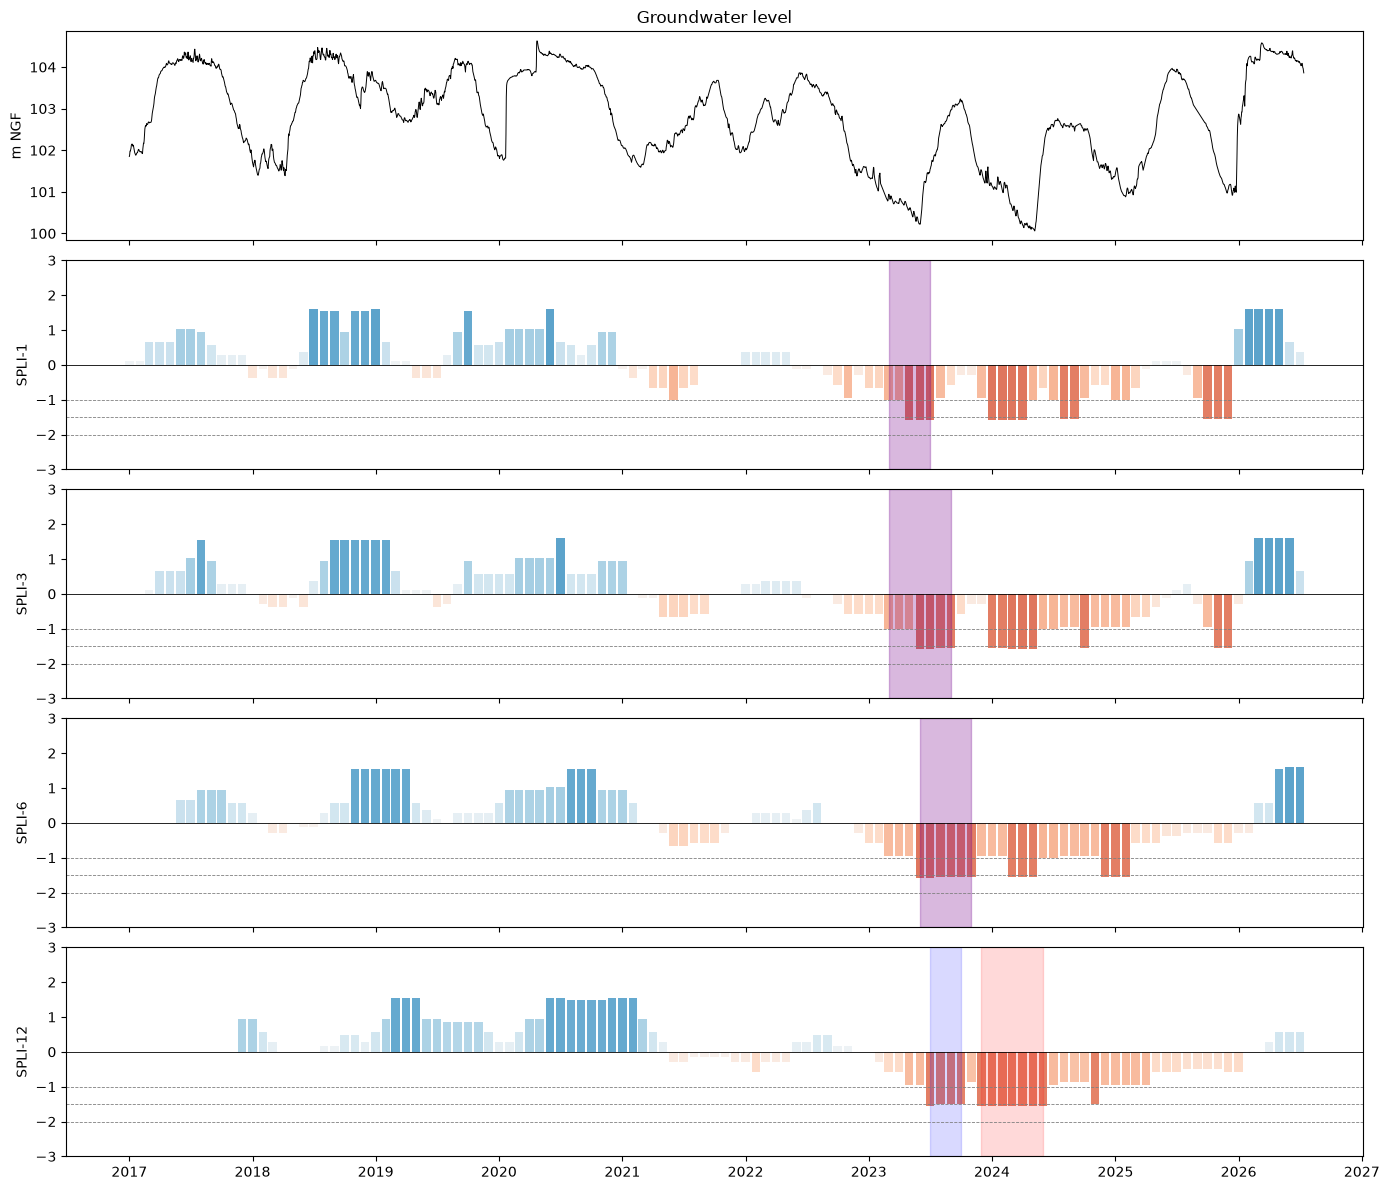

In [42]:
fig, axes = plt.subplots(len(SCALES)+1, 1, figsize=(14, 2.4*(len(SCALES)+1)), sharex=True)
axes[0].plot(df[GWL], color="black", lw=0.7)
axes[0].set_ylabel("m NGF"); axes[0].set_title("Groundwater level")

cmap = plt.get_cmap("RdBu")
tn = mcolors.TwoSlopeNorm(0, -3, 3)
for ax, s in zip(axes[1:], SCALES):
    ser = idx[("SPLI", s)]
    ax.bar(ser.index, ser.values, width=25, color=cmap(tn(ser.values)))
    for y in (-1, -1.5, -2): ax.axhline(y, color="grey", ls="--", lw=0.6)
    ax.axhline(0, color="k", lw=0.6); ax.set_ylabel(f"SPLI-{s}"); ax.set_ylim(-3, 3)
    # shade longest (red) & most-intense (blue) event for THIS scale:
    lg = longest[longest.scale==s].iloc[0]; mi = most_intense[most_intense.scale==s].iloc[0]
    ax.axvspan(lg.start, lg.end, color="red", alpha=.15)
    ax.axvspan(mi.start, mi.end, color="blue", alpha=.15)
plt.tight_layout(); plt.show()

Note: SPLI-k = the standardized index computed over a k-month accumulation window (reported once per month)
- SPLI-1: each month's value uses that single month's groundwater level → jumpy, catches short/flash anomalies.
- SPLI-6: each month's value uses the trailing 6-month average level → smoother, catches seasonal droughts.
- SPLI-12: trailing 12-month average → very smooth, catches long/hydrological droughts (this is groundwater's natural timescale).

### Duration vs intensity bubble chart

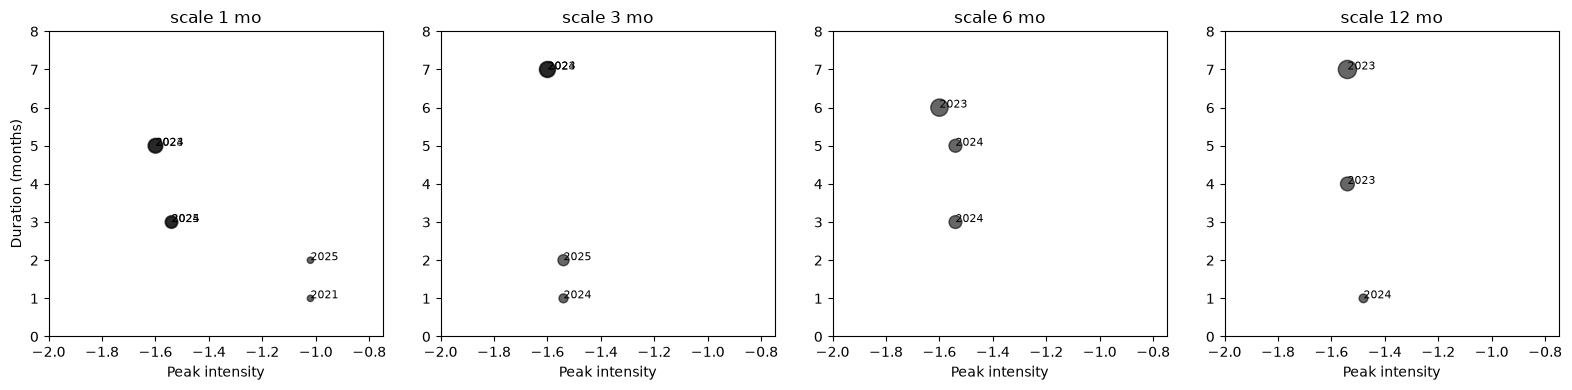

In [43]:
fig, axes = plt.subplots(1, len(SCALES), figsize=(4*len(SCALES), 4))
for ax, s in zip(np.atleast_1d(axes), SCALES):
    e = drought[drought.scale == s]
    ax.scatter(e["peak"], e["duration_m"], s=e["severity"]*40+20, alpha=.6, color="black")
    for _, r in e.iterrows():
        ax.annotate(r["start"].year, (r["peak"], r["duration_m"]), fontsize=8)
    ax.set_xlabel("Peak intensity"); ax.set_title(f"scale {s} mo"); ax.invert_xaxis()
    ax.set_ylim(0,8); ax.set_xlim(-2,-0.75)
axes[0].set_ylabel("Duration (months)"); plt.tight_layout(); plt.show()

### Heatwave detection (percentile-based)

WMO-style: >= `min_days` consecutive days above the **local calendar-day 90th
percentile** of daily Tmax. Percentile-based (not a fixed C) so it adapts to the
site. Reuses run-theory on a daily boolean.

In [44]:
def heatwave_days(tmax, pct=90, window=15, min_days=3): # window is a ± half-width
    """Boolean daily Series: True on days inside a heatwave."""
    doy = tmax.index.dayofyear.to_numpy()
    tmax_val = tmax.to_numpy()
    thr = pd.Series(index=tmax.index, dtype=float)
    for d in range(1,367):
        dist = np.abs((doy)-d)
        mask = np.minimum(dist, 366 -dist) <=  window
        thr[doy ==d] = np.nanpercentile(tmax_val[mask], pct)

    hot = tmax > thr
    run_id = (hot != hot.shift()).cumsum()
    sizes  = hot.groupby(run_id).transform("size")
    return hot & (sizes >= min_days)

if TMAX:
    hw = heatwave_days(df[TMAX]); print("heatwave days:", int(hw.sum()))
else:
    print("No daily Tmax yet; add temperature_2m_max, then run this cell.")

heatwave days: 165


### Compound & lagged analysis

- **Compound dry-hot**: months simultaneously in drought *and* hit by heatwaves 
- **Lag structure**: how many months groundwater (SPLI) trails rainfall (SPI). That lag
  = the aquifer's memory

best lag (months): 2 | r = 0.43 (measures shared variance)


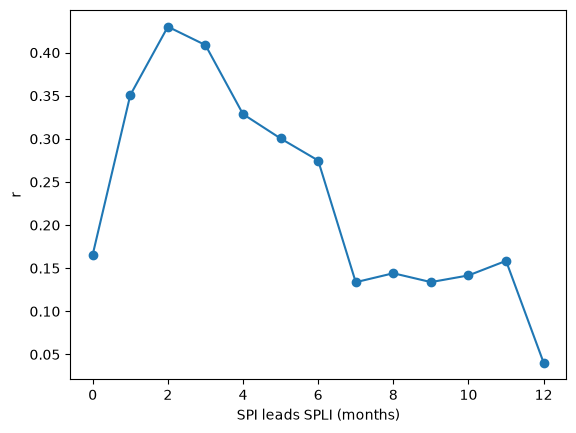

heatwave,False,True
drought,,
False,79,17
True,12,7


,drought,heatwave,compound
date_index,,,
2023-04-01,True,True,True
2023-05-01,True,True,True
2024-01-01,True,True,True
2024-02-01,True,True,True
2024-03-01,True,True,True
2024-04-01,True,True,True
2024-08-01,True,True,True


In [ ]:
# Lag: cross-correlate SPI-1 (cause) vs SPLI-1 (response)
a = idx[("SPI", 1)].dropna() # 1-month precipitation index
b = idx[("SPLI", 1)].dropna() # 1-month groundwater index
common = a.index.intersection(b.index) # set of months present in both series
a, b = a.loc[common], b.loc[common] 
# For each lag L from 0 to 12 months: b.shift(-L) moves SPLI earlier by L months, 
# so month t now lines up with the groundwater value from month t+L.
# hen a.corr(...) computes the Pearson correlation between rainfall at t and groundwater at t+L
corr = {L: a.corr(b.shift(-L)) for L in range(0, 13)}       # SPI leads SPLI by L
# Picks the lag L with the highest correlation
best = max(corr, key=corr.get)
print("best recharge lag (months):", best, "| r =", round(corr[best], 2), "(measures shared variance)")
pd.Series(corr).plot(marker="o"); plt.xlabel("SPI leads SPLI (months)"); plt.ylabel("r"); plt.show()

# Compound dry-hot
drought_month = (idx[("SPLI", 1)] < -1) # where 3-month groundwater is below −1 (in moderate+ drought)
hw_month = hw.resample("MS").sum() > 0 # counts heatwave days per month
comp = pd.concat([drought_month.rename("drought"),
                  hw_month.rename("heatwave")], axis=1).dropna()
comp["compound"] = comp.drought & comp.heatwave
display(pd.crosstab(comp.drought, comp.heatwave), comp[comp.compound])


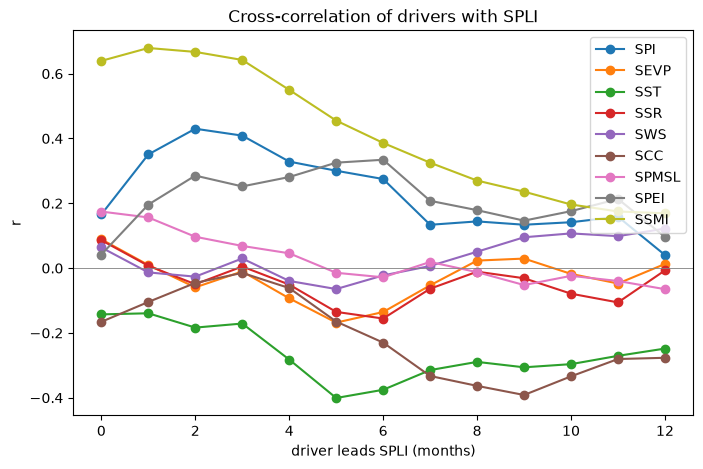

In [88]:
def ccf(driver, response, maxlag=12):
    """Cross-corr of driver(t) vs response(t+L). Returns {lag: r}."""
    common = driver.dropna().index.intersection(response.dropna().index)
    a, b = driver.loc[common], response.loc[common]
    return {L: a.corr(b.shift(-L)) for L in range(maxlag + 1)}

drivers = [t[0] for t in SPEC if t[0] != "SPLI"]   # meteo/soil drivers; SPLI-1 is the response

# ---- overlay CCF of each driver vs SPLI-1 ----
resp = idx[("SPLI", 1)]
plt.figure(figsize=(8, 5))
for name in drivers:
    c = ccf(idx[(name, 1)], resp)
    plt.plot(list(c), list(c.values()), marker="o", label=f"{name}")
plt.axhline(0, color="grey", lw=.6)
plt.xlabel("driver leads SPLI (months)"); plt.ylabel("r")
plt.title("Cross-correlation of drivers with SPLI"); plt.legend(); plt.show()

### Verification

In [46]:
# --- 1. Internal consistency: generic index reproduces the original SPLI ---
assert (standardize_index(df[GWL],1,"mean").dropna()
        - spli_check.dropna()).abs().max() < 1e-9
print("✓ generic SPLI == notebook SPLI")

# --- 2. Distribution check: every index must be ~N(0,1) by construction ---
for (name, s), ser in idx.items():
    m, sd = ser.mean(), ser.std()
    assert abs(m) < 0.15 and 0.8 < sd < 1.2, f"{name}-{s} not standardized: μ={m:.2f} σ={sd:.2f}"
print("✓ all indices standardized")

# --- 3. Known drought: worst SPLI-12 trough must fall in the 2022–2024 P.-O. crisis ---
worst = idx[("SPLI",12)].idxmin()
print("Worst 12-mo drought:", worst.date(), "→", "✓" if 2022 <= worst.year <= 2024 else "✗ CHECK")

# --- 4. Known wet event: Storm Gloria (Jan 2020) should be a strong positive SPI-1 ---
gloria = idx[("SPI",1)].loc["2020-01-01"]
print("SPI-1 Jan 2020:", round(float(gloria),2), "→", "✓" if float(gloria) > 1 else "✗ CHECK")

# --- 5. Physical lag: groundwater should trail rainfall (best lag ≥ 1 month, not 0) ---
print("Best SPI→SPLI lag:", best, "months →", "✓" if best >= 1 else "✗ suspicious")

✓ generic SPLI == notebook SPLI
✓ all indices standardized
Worst 12-mo drought: 2023-07-01 → ✓
SPI-1 Jan 2020: 1.6 → ✓
Best SPI→SPLI lag: 3 months → ✓
